# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1990s 12us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

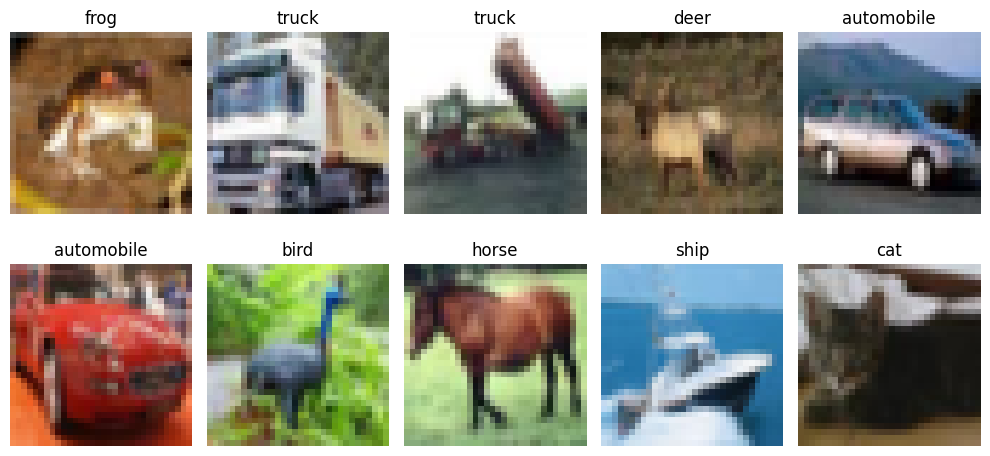

In [4]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [6]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 25s 34ms/step - accuracy: 0.2713 - loss: 1.9974 - val_accuracy: 0.3172 - val_loss: 1.8584
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 38s 29ms/step - accuracy: 0.3256 - loss: 1.8628 - val_accuracy: 0.3546 - val_loss: 1.8013
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3451 - loss: 1.8062 - val_accuracy: 0.3506 - val_loss: 1.7610
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 40s 28ms/step - accuracy: 0.3588 - loss: 1.7760 - val_accuracy: 0.3818 - val_loss: 1.7400
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3677 - loss: 1.7437 - val_accuracy: 0.3990 - val_loss: 1.6991
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 28ms/step - accuracy: 0.3711 - loss: 1.7281 - val_accuracy: 0.4186 - val_loss: 1.6625
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3794 - loss: 1.7180 - val_accuracy: 0.4138 - val_loss: 1.6604
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - accuracy: 0.3869 - loss: 1.6875 - 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 51s 70ms/step - accuracy: 0.2087 - loss: 2.1026 - val_accuracy: 0.2732 - val_loss: 1.9703
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.2768 - loss: 1.9472 - val_accuracy: 0.3210 - val_loss: 1.9158
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.2912 - loss: 1.9118 - val_accuracy: 0.3244 - val_loss: 1.8692
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.3037 - loss: 1.8829 - val_accuracy: 0.3548 - val_loss: 1.8454
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3144 - loss: 1.8617 - val_accuracy: 0.3464 - val_loss: 1.8455
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 48s 68ms/step - accuracy: 0.3220 - loss: 1.8462 - val_accuracy: 0.3648 - val_loss: 1.7935
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 66ms/step - accuracy: 0.3259 - loss: 1.8344 - val_accuracy: 0.3638 - val_loss: 1.8420
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 68ms/step - accuracy: 0.3287 - loss: 1.8271 - 

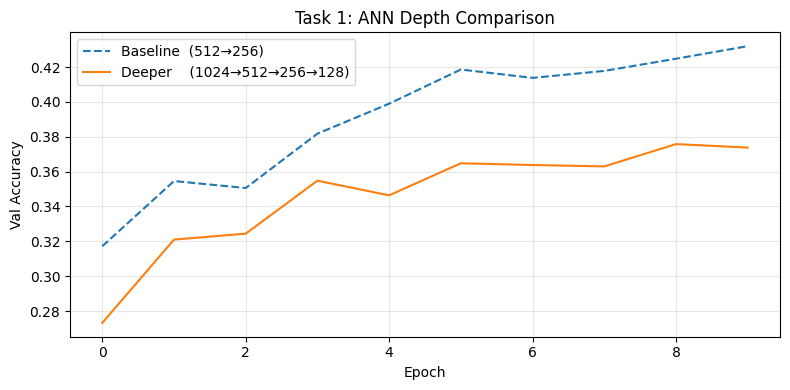

In [15]:
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.4),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history_v2 = ann_model_v2.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

# Comparison plot
plt.figure(figsize=(8, 4))
plt.plot(ann_history.history['val_accuracy'],    label='Baseline  (512→256)',          linestyle='--')
plt.plot(ann_history_v2.history['val_accuracy'], label='Deeper    (1024→512→256→128)', linestyle='-')
plt.title('Task 1: ANN Depth Comparison')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4356 - loss: 1.6183
ANN Test Accuracy: 0.43560001254081726


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [10]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 93s 123ms/step - accuracy: 0.4746 - loss: 1.4815 - val_accuracy: 0.5666 - val_loss: 1.2261
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 124ms/step - accuracy: 0.6151 - loss: 1.1006 - val_accuracy: 0.6412 - val_loss: 1.0065
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 86s 123ms/step - accuracy: 0.6700 - loss: 0.9385 - val_accuracy: 0.5904 - val_loss: 1.2472
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 125ms/step - accuracy: 0.7170 - loss: 0.8178 - val_accuracy: 0.6554 - val_loss: 1.0352
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.7492 - loss: 0.7205 - val_accuracy: 0.6664 - val_loss: 0.9905
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 124ms/step - accuracy: 0.7750 - loss: 0.6396 - val_accuracy: 0.6648 - val_loss: 1.0229
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 123ms/step - accuracy: 0.7962 - loss: 0.5842 - val_accuracy: 0.7000 - val_loss: 0.9574
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 124ms/step - accuracy: 0.8145 - loss:

In [16]:
# Scale CNN filters 32→64→128
cnn_model_t2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_t2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Filter progression:")
for layer in cnn_model_t2.layers:
    if hasattr(layer, 'filters'):
        print(f"  {layer.name}: {layer.filters} filters  →  output shape {layer.output.shape}")

Filter progression:
  conv2d_11: 32 filters  →  output shape (None, 30, 30, 32)
  conv2d_12: 64 filters  →  output shape (None, 13, 13, 64)
  conv2d_13: 128 filters  →  output shape (None, 4, 4, 128)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [19]:
# Train for 20 epochs
cnn_model_20 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_20 = cnn_model_20.fit(
    x_train_norm, y_train,
    epochs=20,                  # ← changed from 10
    validation_split=0.1,
    batch_size=64
)

# Compare 10 vs 20 epoch curves
plt.figure(figsize=(8, 4))
plt.plot(cnn_history.history['val_accuracy'],    label='CNN 10 epochs', linestyle='--')
plt.plot(cnn_history_20.history['val_accuracy'], label='CNN 20 epochs', linestyle='-')
plt.title('Task 3: Effect of Increasing Epochs')
plt.xlabel('Epoch')
plt.ylabel('Val Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Epoch 1/20


Exception ignored in: <function WeakKeyDictionary.__init__.<locals>.remove at 0x7ba3e135cae0>
Traceback (most recent call last):
  File "/usr/lib/python3.12/weakref.py", line 369, in remove
    def remove(k, selfref=ref(self)):

KeyboardInterrupt: 


 89/704 ━━━━━━━━━━━━━━━━━━━━ 1:17 126ms/step - accuracy: 0.2357 - loss: 2.1732

KeyboardInterrupt: 

In [24]:
# EarlyStopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',           # watches validation loss
    patience=5,
    restore_best_weights=True,    # rolls back to best epoch automatically
    verbose=1
)

cnn_model_es = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model_es.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history_es = cnn_model_es.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]        # ← EarlyStopping plugged in here
)

actual_epochs = len(cnn_history_es.history['val_accuracy'])
print(f"\nEarlyStopping triggered — trained {actual_epochs}/20 epochs")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 127ms/step - accuracy: 0.4633 - loss: 1.4978 - val_accuracy: 0.5630 - val_loss: 1.1913
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 142s 127ms/step - accuracy: 0.6042 - loss: 1.1289 - val_accuracy: 0.6450 - val_loss: 0.9928
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 126ms/step - accuracy: 0.6612 - loss: 0.9699 - val_accuracy: 0.6446 - val_loss: 1.0394
Epoch 4/20
669/704 ━━━━━━━━━━━━━━━━━━━━ 4s 123ms/step - accuracy: 0.6989 - loss: 0.8581

KeyboardInterrupt: 

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6864 - loss: 1.1698
CNN Test Accuracy: 0.6863999962806702


## 📈 Compare Learning Curves

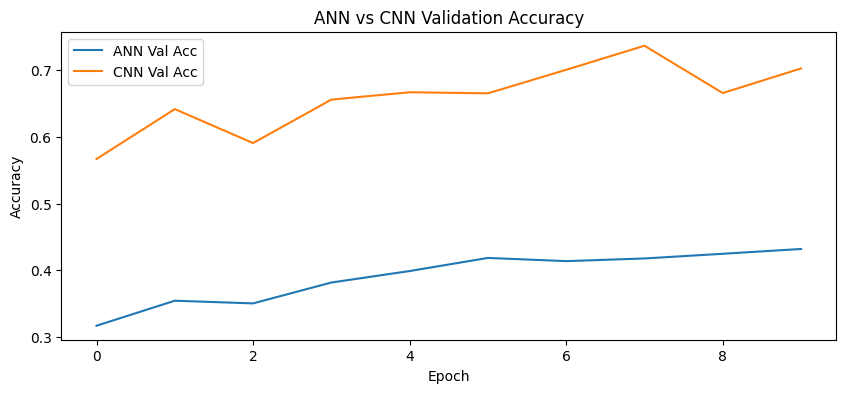

In [12]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

aug_cnn_model = models.Sequential([
    # Augmentation layers — only active during training
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),

    # CNN body
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

aug_history = aug_cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test)
print(f"Augmented CNN Test Accuracy: {aug_test_acc:.4f}")

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 105s 143ms/step - accuracy: 0.3989 - loss: 1.6696 - val_accuracy: 0.5194 - val_loss: 1.3605
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 140ms/step - accuracy: 0.5059 - loss: 1.4004 - val_accuracy: 0.4982 - val_loss: 1.4439
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 140ms/step - accuracy: 0.5485 - loss: 1.2890 - val_accuracy: 0.5998 - val_loss: 1.1061
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 99s 141ms/step - accuracy: 0.5764 - loss: 1.2124 - val_accuracy: 0.6038 - val_loss: 1.1467
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 100s 142ms/step - accuracy: 0.6020 - loss: 1.1456 - val_accuracy: 0.6114 - val_loss: 1.1327
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 140ms/step - accuracy: 0.6187 - loss: 1.0988 - val_accuracy: 0.5548 - val_loss: 1.4618
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5975 - loss: 1.1353
Augmented CNN Test Accuracy: 0.5975


# 📊 Final Comparison Table

In [23]:
ann_v2_test_acc = ann_model_v2.evaluate(x_test_flat, y_test, verbose=0)[1]
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(x_test_norm, y_test, verbose=0)

comparison = pd.DataFrame({
    "Model": [
        "ANN Baseline (512→256)",
        "ANN Deeper (1024→512→256→128)",
        "CNN Baseline (32→64→128)",
        "CNN + Augmentation + EarlyStopping"
    ],
    "Test Accuracy": [
        round(ann_test_acc, 4),
        round(ann_v2_test_acc, 4),
        round(cnn_test_acc, 4),
        round(aug_test_acc, 4)
    ],
    "Notes": [
        "No spatial awareness",
        "More depth, marginal gain",
        "Spatial features, big jump",
        "Best generalisation"
    ]
})
comparison

,Model,Test Accuracy
0,ANN,0.4356
1,CNN,0.6864


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**